In this notebook, we applied all filters to a UAV log data synched at vehicle odometory log 100Hz sampling rate.

In [1]:
import os
import sys
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report, print_error_report
from utils import lla_to_enu, lla_to_ned

from data_loader import UAV_DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm
from decimal import Decimal, getcontext
from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../../data"

loader = UAV_DataLoader(root_path=root_path, sequence_nr="log0000")

In [3]:
df1 = loader.ref_df.loc[(loader.ref_df["device"] == "px4_vehicle_odom")]

In [4]:
plt_config = {
    'xlim': (-30, 15),
    'ylim': (-30, 10),
    'zlim': (-300, 0)
}

In [5]:
def get_error_df(error_list):
    mae_error = get_error_from_list(error_list, e_type=ErrorEnum.MAE)
    
    rmse_error = get_error_from_list(error_list, e_type=ErrorEnum.RMSE)
    
    max_error = get_error_from_list(error_list, e_type=ErrorEnum.MAX)
    
    errors = np.array([
        mae_error, rmse_error, max_error
    ])
    df = pd.DataFrame(errors, 
                index=["MAE", "RMSE", "MAX"], 
                columns=["EKF", "UKF", "PF", "EnKF", "CKF"])
    return df

# Apply Filters

## EKF

In [10]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

In [11]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

ekf_mu_x = []
ekf_mu_y = []
ekf_mu_z = []

gps_list = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']] # always vehicle odometory
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:

        # Find corresponding imu and gps data based on the timestamp
        imu_data = loader.voxl_imu0_df\
                        .iloc[np.argmin(np.abs((loader.voxl_imu0_df['timestamp(ns)'] / 1000) - data_ref['timestamp']))]
        gps_data = loader.px4_gps_df\
                        .iloc[np.argmin(np.abs(loader.px4_gps_df['timestamp'] - data_ref['timestamp']))]
        
        # Call Time update step
        u = imu_data[df_reference['voxl_imu0']['columns']].values
        ekf.predict_setup1_2(u=u, dt=dt, Q=ekf.Q)
            
        x_hat = ekf.x.copy()
        ekf_mu_x.append(x_hat[0, 0])
        ekf_mu_y.append(x_hat[1, 0])
        ekf_mu_z.append(x_hat[2, 0])

        
        # Call Measurement update step
        
        gps_ned = lla_to_ned(
            gps_data[loader.gps_pose_columns].values.reshape(-1, 1),
            original_position
        ).T[0]
        z_gps = np.array([
            gps_ned[0],
            gps_ned[1],
            gps_ned[2],
        ])
        r_gps = gps_data[loader.gps_pos_var_columns].values ** 2
        R_gps = np.eye(H.shape[0]) * r_gps
        ekf.update(z=z_gps, R=R_gps)   
        
        z_vehicle_odom = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
        r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values ** 2
        if np.isnan(r_vo.sum()):
            R_vo = ekf.R_vo
        else:
            R_vo = np.eye(r_vo.shape[0]) * r_vo
        
        ekf.update(z=z_vehicle_odom, R=R_vo)
                
        gps_list.append(z_gps)
        
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


ekf_mu_x = np.array(ekf_mu_x)
ekf_mu_y = np.array(ekf_mu_y)
ekf_mu_z = np.array(ekf_mu_z)

gps_list = np.array(gps_list)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 5254/5254 [00:08<00:00, 586.27it/s]


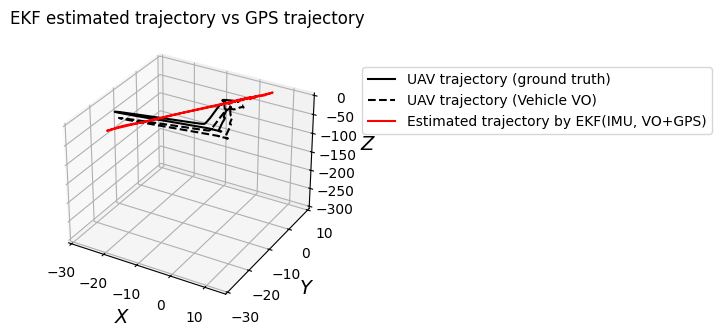

In [12]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EKF estimated trajectory vs GPS trajectory")

x, y, z = gps_list.T
ax1.plot(x, 
         y, 
         z, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ekf_mu_x, ekf_mu_y, ekf_mu_z, label='Estimated trajectory by EKF(IMU, VO+GPS)', color='red')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

ax1.set_xlim(plt_config['xlim'])
ax1.set_ylim(plt_config['ylim'])
ax1.set_zlim(plt_config['zlim'])

ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
fig.tight_layout()
plt.show()

In [13]:
ekf_imu_vo_gps_error = get_error_report(
    gps_list,
    np.array([ekf_mu_x, ekf_mu_y, ekf_mu_z]).T
)

print_error_report(
    report=ekf_imu_vo_gps_error,
    title="Deviation between EKF(IMU, VO+GPS) estimated pose and GPS"
)


----- Deviation between EKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 4.792 m
Root Mean Squared Error: 6.665 m
Maximum Error: 19.768 m
---------------------------------------------------------------------



## UKF

In [14]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

alpha_setup = 10.
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

In [15]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

ukf_mu_x = []
ukf_mu_y = []
ukf_mu_z = []

gps_list = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']] # always vehicle odometory
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:

        # Find corresponding imu and gps data based on the timestamp
        imu_data = loader.voxl_imu0_df\
                        .iloc[np.argmin(np.abs((loader.voxl_imu0_df['timestamp(ns)'] / 1000) - data_ref['timestamp']))]
        gps_data = loader.px4_gps_df\
                        .iloc[np.argmin(np.abs(loader.px4_gps_df['timestamp'] - data_ref['timestamp']))]
        
        # Call Time update step
        u = imu_data[df_reference['voxl_imu0']['columns']].values
        ukf.predict_setup1_2(u=u, dt=dt, Q=ukf.Q)
            
        x_hat = ukf.x.copy()
        ukf_mu_x.append(x_hat[0, 0])
        ukf_mu_y.append(x_hat[1, 0])
        ukf_mu_z.append(x_hat[2, 0])
        
        # Call Measurement update step
        
        gps_ned = lla_to_ned(
            gps_data[loader.gps_pose_columns].values.reshape(-1, 1),
            original_position
        ).T[0]
        z_gps = np.array([
            gps_ned[0],
            gps_ned[1],
            gps_ned[2],
        ])
        r_gps = gps_data[loader.gps_pos_var_columns].values ** 2
        R_gps = np.eye(r_vo.shape[0]) * r_gps
        ukf.update(z=z_gps, R=R_gps)   
        
        z_vehicle_odom = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
        r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values ** 2
        if np.isnan(r_vo.sum()):
            R_vo = ukf.R_vo
        else:
            R_vo = np.eye(r_vo.shape[0]) * r_vo
        
        ukf.update(z=z_vehicle_odom, R=R_vo)
                
        gps_list.append(z_gps)
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


ukf_mu_x = np.array(ukf_mu_x)
ukf_mu_y = np.array(ukf_mu_y)
ukf_mu_z = np.array(ukf_mu_z)

gps_list = np.array(gps_list)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 5254/5254 [00:11<00:00, 468.67it/s]


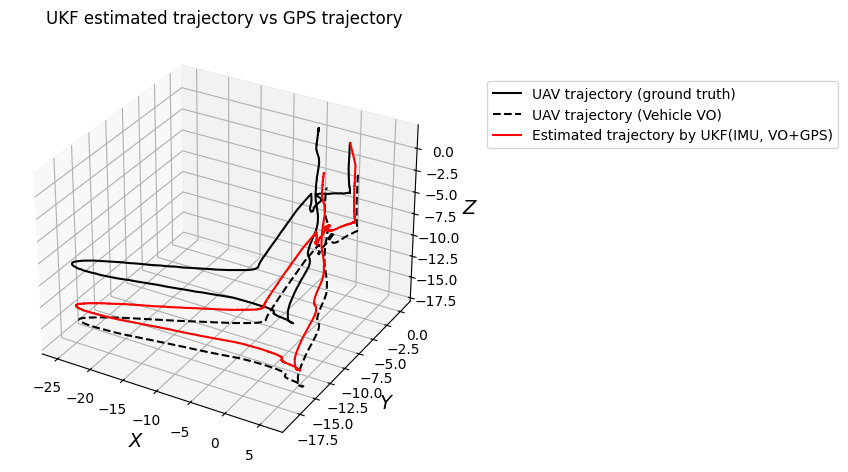

In [16]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("UKF estimated trajectory vs GPS trajectory")

x, y, z = gps_list.T
ax1.plot(x, 
         y, 
         z, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ukf_mu_x, ukf_mu_y, ukf_mu_z, label='Estimated trajectory by UKF(IMU, VO+GPS)', color='red')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [17]:
ukf_imu_vo_gps_error = get_error_report(
    gps_list,
    np.array([ukf_mu_x, ukf_mu_y, ukf_mu_z]).T
)

print_error_report(
    report=ukf_imu_vo_gps_error,
    title="Deviation between UKF(IMU, VO+GPS) estimated pose and GPS"
)


----- Deviation between UKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 2.077 m
Root Mean Squared Error: 2.43 m
Maximum Error: 4.932 m
---------------------------------------------------------------------



## PF

In [18]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

importance_resampling = True

pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

In [15]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

pf_mu_x = []
pf_mu_y = []
pf_mu_z = []

gps_list = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']] # always vehicle odometory
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:

        # Find corresponding imu and gps data based on the timestamp
        imu_data = loader.voxl_imu0_df\
                        .iloc[np.argmin(np.abs((loader.voxl_imu0_df['timestamp(ns)'] / 1000) - data_ref['timestamp']))]
        gps_data = loader.px4_gps_df\
                        .iloc[np.argmin(np.abs(loader.px4_gps_df['timestamp'] - data_ref['timestamp']))]
        
        # Call Time update step
        u = imu_data[df_reference['voxl_imu0']['columns']].values
        pf.predict_setup1_2(u=u, dt=dt, Q=pf.Q)
            
        x_hat, _ = pf.estimate()
        pf_mu_x.append(x_hat[0])
        pf_mu_y.append(x_hat[1])
        pf_mu_z.append(x_hat[2])
        
        # Call Measurement update step
        
        gps_ned = lla_to_ned(
            gps_data[loader.gps_pose_columns].values.reshape(-1, 1),
            original_position
        ).T[0]
        z_gps = np.array([
            gps_ned[0],
            gps_ned[1],
            gps_ned[2],
        ])
        r_gps = gps_data[loader.gps_pos_var_columns].values ** 2
        R_gps = np.eye(r_vo.shape[0]) * r_gps
        pf.update(z=z_gps, R=R_gps)   
        
        z_vehicle_odom = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
        r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values ** 2
        if np.isnan(r_vo.sum()):
            R_vo = pf.R_vo
        else:
            R_vo = np.eye(r_vo.shape[0]) * r_vo
        
        pf.update(z=z_vehicle_odom, R=R_vo)

        gps_list.append(z_gps)
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


pf_mu_x = np.array(pf_mu_x)
pf_mu_y = np.array(pf_mu_y)
pf_mu_z = np.array(pf_mu_z)

gps_list = np.array(gps_list)

100%|█████████████████████████████████████████████████████████████████████████| 5254/5254 [05:38<00:00, 15.53it/s]


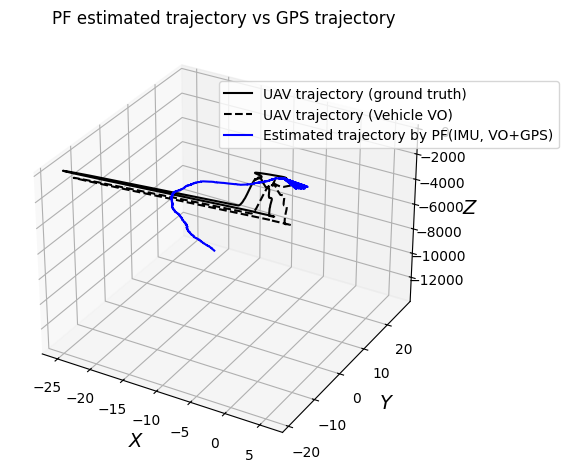

In [16]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("PF estimated trajectory vs GPS trajectory")

x, y, z = gps_list.T
ax1.plot(x, 
         y, 
         z, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(pf_mu_x, pf_mu_y, pf_mu_z, label='Estimated trajectory by PF(IMU, VO+GPS)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [17]:
pf_imu_vo_gps_error = get_error_report(
    gps_list,
    np.array([pf_mu_x, pf_mu_y, pf_mu_z]).T
)

print_error_report(
    report=pf_imu_vo_gps_error,
    title="Deviation between PF(IMU, VO+GPS) estimated pose and GPS"
)

----- Deviation between PF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 1542.647
Root Mean Squared Error: 3558.597
Maximum Error: 13741.192



## EnKF

In [18]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

n_ensemble = 64
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)

In [19]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

enkf_mu_x = []
enkf_mu_y = []
enkf_mu_z = []

gps_list = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']] # always vehicle odometory
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:

        # Find corresponding imu and gps data based on the timestamp
        imu_data = loader.voxl_imu0_df\
                        .iloc[np.argmin(np.abs((loader.voxl_imu0_df['timestamp(ns)'] / 1000) - data_ref['timestamp']))]
        gps_data = loader.px4_gps_df\
                        .iloc[np.argmin(np.abs(loader.px4_gps_df['timestamp'] - data_ref['timestamp']))]
        
        # Call Time update step
        u = imu_data[df_reference['voxl_imu0']['columns']].values
        enkf.predict_setup1_2(u=u, dt=dt, Q=enkf.Q)
            
        x_hat = enkf.x.copy()
        enkf_mu_x.append(x_hat[0])
        enkf_mu_y.append(x_hat[1])
        enkf_mu_z.append(x_hat[2])
        
        # Call Measurement update step
        
        gps_ned = lla_to_ned(
            gps_data[loader.gps_pose_columns].values.reshape(-1, 1),
            original_position
        ).T[0]
        z_gps = np.array([
            gps_ned[0],
            gps_ned[1],
            gps_ned[2],
        ])
        r_gps = gps_data[loader.gps_pos_var_columns].values ** 2
        R_gps = np.eye(r_vo.shape[0]) * r_gps
        enkf.update(z=z_gps, R=R_gps)   
        
        z_vehicle_odom = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
        r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values ** 2
        if np.isnan(r_vo.sum()):
            R_vo = enkf.R_vo
        else:
            R_vo = np.eye(r_vo.shape[0]) * r_vo
        
        enkf.update(z=z_vehicle_odom, R=R_vo)

        gps_list.append(z_gps)
        
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


enkf_mu_x = np.array(enkf_mu_x)
enkf_mu_y = np.array(enkf_mu_y)
enkf_mu_z = np.array(enkf_mu_z)

gps_list = np.array(gps_list)

100%|████████████████████████████████████████████████████████████████████████| 5254/5254 [00:11<00:00, 438.42it/s]


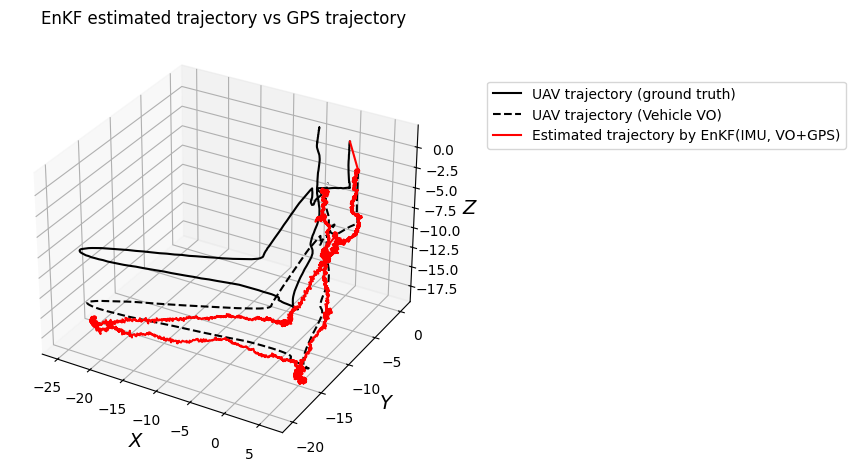

In [20]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EnKF estimated trajectory vs GPS trajectory")

x, y, z = gps_list.T
ax1.plot(x, 
         y, 
         z, 
         label='UAV trajectory (ground truth)', 
         color='black')
x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')


ax1.plot(enkf_mu_x, enkf_mu_y, enkf_mu_z, label='Estimated trajectory by EnKF(IMU, VO+GPS)', color='red')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [21]:
enkf_imu_vo_gps_error = get_error_report(
    gps_list,
    np.array([enkf_mu_x, enkf_mu_y, enkf_mu_z]).T
)

print_error_report(
    report=enkf_imu_vo_gps_error,
    title="Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS"
)

----- Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 3.386
Root Mean Squared Error: 4.082
Maximum Error: 8.956



## CKF

In [22]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

In [23]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

ckf_mu_x = []
ckf_mu_y = []
ckf_mu_z = []

gps_list = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']] # always vehicle odometory
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:

        # Find corresponding imu and gps data based on the timestamp
        imu_data = loader.voxl_imu0_df\
                        .iloc[np.argmin(np.abs((loader.voxl_imu0_df['timestamp(ns)'] / 1000) - data_ref['timestamp']))]
        gps_data = loader.px4_gps_df\
                        .iloc[np.argmin(np.abs(loader.px4_gps_df['timestamp'] - data_ref['timestamp']))]
        
        # Call Time update step
        u = imu_data[df_reference['voxl_imu0']['columns']].values
        ckf.predict_setup1_2(u=u, dt=dt, Q=ckf.Q)
            
        x_hat = ckf.x.copy()
        ckf_mu_x.append(x_hat[0, 0])
        ckf_mu_y.append(x_hat[1, 0])
        ckf_mu_z.append(x_hat[2, 0])
        
        # Call Measurement update step
        
        gps_ned = lla_to_ned(
            gps_data[loader.gps_pose_columns].values.reshape(-1, 1),
            original_position
        ).T[0]
        z_gps = np.array([
            gps_ned[0],
            gps_ned[1],
            gps_ned[2],
        ])
        r_gps = gps_data[loader.gps_pos_var_columns].values ** 2
        R_gps = np.eye(r_vo.shape[0]) * r_gps
        ckf.update(z=z_gps, R=R_gps)   
        
        z_vehicle_odom = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
        r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values ** 2
        if np.isnan(r_vo.sum()):
            R_vo = ckf.R_vo
        else:
            R_vo = np.eye(r_vo.shape[0]) * r_vo
        
        ckf.update(z=z_vehicle_odom, R=ckf.R_vo)

        gps_list.append(z_gps)
        
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


ckf_mu_x = np.array(ckf_mu_x)
ckf_mu_y = np.array(ckf_mu_y)
ckf_mu_z = np.array(ckf_mu_z)

gps_list = np.array(gps_list)

100%|████████████████████████████████████████████████████████████████████████| 5254/5254 [00:08<00:00, 656.41it/s]


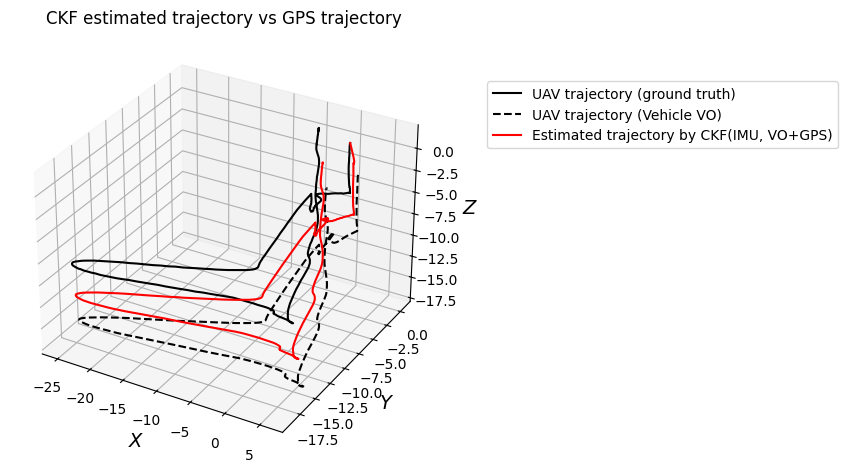

In [24]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("CKF estimated trajectory vs GPS trajectory")

x, y, z = gps_list.T
ax1.plot(x, 
         y, 
         z, 
         label='UAV trajectory (ground truth)', 
         color='black')
x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ckf_mu_x, ckf_mu_y, ckf_mu_z, label='Estimated trajectory by CKF(IMU, VO+GPS)', color='red')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [25]:
ckf_imu_vo_gps_error = get_error_report(
    gps_list,
    np.array([ckf_mu_x, ckf_mu_y, ckf_mu_z]).T
)

print_error_report(
    report=ckf_imu_vo_gps_error,
    title="Deviation between CKF(IMU, VO+GPS) estimated pose and GPS"
)

----- Deviation between CKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 1.565
Root Mean Squared Error: 1.844
Maximum Error: 3.845



## Conclusion

In [26]:
print(f"Vehicle Odometory sampling rate: {round(len(df1) / ((df1['timestamp'].iloc[-1] - df1['timestamp'].iloc[0]) / 1_000_000), 2)}Hz")

Vehicle Odometory sampling rate: 99.85Hz


In [27]:
get_error_df(error_list=[
    ekf_imu_vo_gps_error, 
    ukf_imu_vo_gps_error, 
    pf_imu_vo_gps_error, 
    enkf_imu_vo_gps_error, 
    ckf_imu_vo_gps_error
])

,EKF,UKF,PF,EnKF,CKF
MAE,4.792,2.077,1542.647,3.386,1.565
RMSE,6.665,2.430,3558.597,4.082,1.844
MAX,19.768,4.932,13741.192,8.956,3.845


In this notebook, all Kalman filters are applied to the UAV data, where IMU, Vehicle Odometory, and GPS are synched at the Vehicle Odometory sampling rate, 100Hz.

The result shows that the estimation of quadcopter's position is balanced between the GPS and vehicle odometory. Since the position error of the vehicle odometory, which is taken from the columns, position_variance[0], position_variance[1], position_variance[2] in the vehicle odometory file, is much smaller than the position error of GPS, the estimated trajectory is still shifted to the vehicle odometory side.

The best score is marked by the CKF in all metrics.